In [3]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

In [39]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from abm.model import SocialGPModel, as_batch_fixed
from abm.rewards import make_correlated_dog
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory, animate_heatmap_trajectory
from abm.batch_analysis import (
    run_condition_batches,
    summarize_condition_timeseries,
    summarize_mean_reward_last_steps,
    plot_condition_comparison,
    summarize_batch_metrics,
    plot_metric_suite_by_lambda,
 )

sns.set_theme(style="whitegrid")

# Dyadic simulations
This notebook explores different aspects of two agents interacting (on correlated Mexican hat rewards)

## 1. Explore two agents, human adult parameters
This section dives deeper into individual agents for single runs

### 1.a Homogeneous agents

In [17]:
grid_size   = 33
lambda_true = 4.5
# Naito: lambda = 1.59 vs true of 1.5
naito_lambda_ratio = 1.59 / 1.5
# Witt VS: lamdba= 2.45 vs true of 2
witt_lambda_ratio = 2.45 / 2

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 1.0
}

# NOTE: Mesa batch_run treats iterables as sweep dimensions.
# Wrap reporter lists in an outer list so they are passed as one fixed value.
reporters = ["global_max", "local_max", "reward"] #, "policy", "choice","value"]

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito_pair': {
        "n": 2,
        "grid_size": grid_size,
        "beta": 0.1,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0.18,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'witt_VS': {
        "n": 2,
        "grid_size": grid_size,
        "beta": 0.07,
        "length_scale": lambda_true*witt_lambda_ratio,
        "tau": 0.09,
        "alpha": 0.12,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]

    }
}

In [18]:
rng       = np.random.default_rng(42)
max_steps = 400

batch_results = mesa.batch_run(
    SocialGPModel,
    rng=rng,
    parameters=params['witt_VS'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

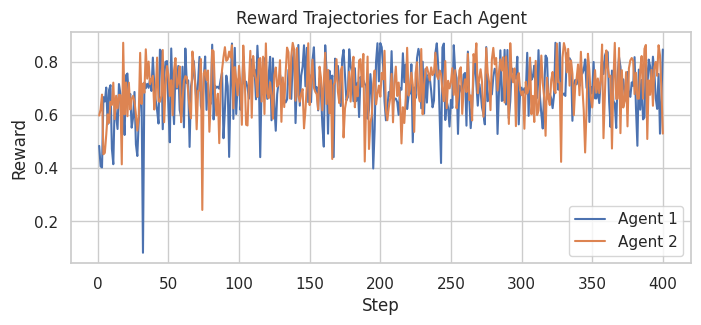

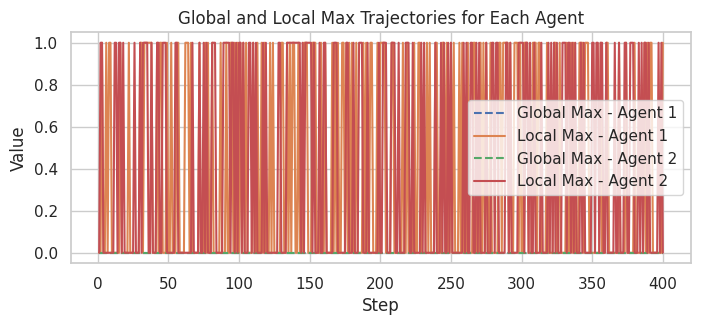

In [19]:
df_batch = pd.DataFrame(batch_results)

# Plot reward trajectories for each agent
plt.figure(figsize=(8, 3))
for agent_id in df_batch['AgentID'].unique():
    agent_data = df_batch[df_batch['AgentID'] == agent_id]
    plt.plot(agent_data['Step'], agent_data['reward'], label=f'Agent {agent_id}')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Trajectories for Each Agent')
plt.legend()
plt.show()

# Plot global and local max trajectories for each agent
plt.figure(figsize=(8, 3))
for agent_id in df_batch['AgentID'].unique():
    agent_data = df_batch[df_batch['AgentID'] == agent_id]
    plt.plot(agent_data['Step'], agent_data['global_max'], label=f'Global Max - Agent {agent_id}', linestyle='--')
    plt.plot(agent_data['Step'], agent_data['local_max'], label=f'Local Max - Agent {agent_id}', linestyle='-')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Global and Local Max Trajectories for Each Agent')
plt.legend()
plt.show()

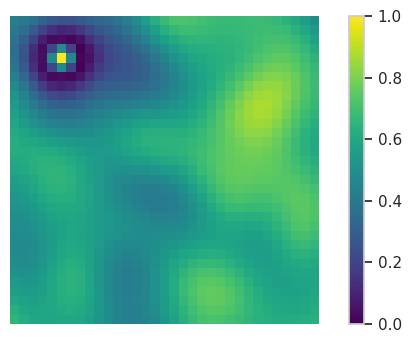

In [9]:
rng    = np.random.default_rng(42)
reward = make_correlated_dog(rng=rng, grid_size=grid_size, length_scale=lambda_true)[0]
plot_reward_grid(reward)

In [ ]:
# Use animate_heatmap_trajectory to plot value evolution for each focal agent
for focal_agent in [1]:#sorted(df_batch['AgentID'].unique()):
    animate_heatmap_trajectory(
        df_batch,
        heatmap_col='value',
        choice_col='choice',
        focal_agent=focal_agent,
        agent_id_col='AgentID',
        step_col='Step',
        fps=1,
        save_path=f'agent_{focal_agent}_value_trajectory.gif',
    )

KeyError: "Column 'value' not found in dataframe."

### 1.b Heterogeneous agents

In [45]:
grid_size   = 33
lambda_true = 4.5
# From literature: ratio of estimated human parameter to true lambda in the reward function
naito_lambda_ratio = 1.59 / 1.5
wittVS_lambda_ratio = 2.45 / 2
giron58_lambda_ratio = 0.43/4

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 1.0
}

# NOTE: Mesa batch_run treats iterables as sweep dimensions.
# Wrap reporter lists in an outer list so they are passed as one fixed value.
reporters = ["global_max", "local_max", "reward", "policy", "choice","value"]

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito_pair': {
        "n": 2,
        "grid_size": grid_size,
        "beta": 0.1,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0.18,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'witt_VS': {
        "n": 2,
        "grid_size": grid_size,
        "beta": 0.07,
        "length_scale": lambda_true*wittVS_lambda_ratio,
        "tau": 0.09,
        "alpha": 0.12,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    },
    'giron_5-8': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.53,
        "length_scale": lambda_true*giron58_lambda_ratio,
        "tau": 0.02,
        "alpha": 0.12,  # No VS in Giron, from Witt
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'WittVS_Giron5-8_hetero': {
        "n": 2,
        "grid_size": grid_size,
        "beta": as_batch_fixed([0.07, 0.53]),
        "length_scale": as_batch_fixed([lambda_true*wittVS_lambda_ratio, lambda_true*giron58_lambda_ratio]),
        "tau": as_batch_fixed([0.09, 0.02]),
        "alpha": as_batch_fixed([0.12, 0.12]),  # No VS in Giron, from Witt
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": [reporters]
    }
}

In [46]:
rng       = np.random.default_rng(42)
max_steps = 30

batch_results = mesa.batch_run(
    SocialGPModel,
    rng=rng,
    parameters=params['WittVS_Giron5-8_hetero'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

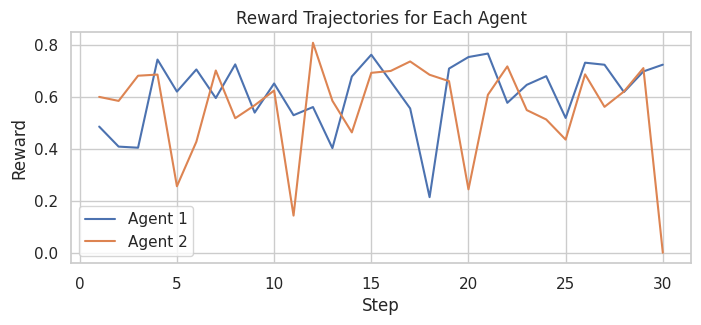

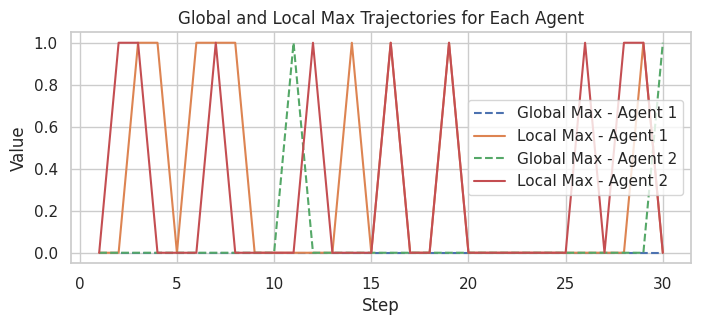

In [47]:
df_batch = pd.DataFrame(batch_results)

# Plot reward trajectories for each agent
plt.figure(figsize=(8, 3))
for agent_id in df_batch['AgentID'].unique():
    agent_data = df_batch[df_batch['AgentID'] == agent_id]
    plt.plot(agent_data['Step'], agent_data['reward'], label=f'Agent {agent_id}')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward Trajectories for Each Agent')
plt.legend()
plt.show()

# Plot global and local max trajectories for each agent
plt.figure(figsize=(8, 3))
for agent_id in df_batch['AgentID'].unique():
    agent_data = df_batch[df_batch['AgentID'] == agent_id]
    plt.plot(agent_data['Step'], agent_data['global_max'], label=f'Global Max - Agent {agent_id}', linestyle='--')
    plt.plot(agent_data['Step'], agent_data['local_max'], label=f'Local Max - Agent {agent_id}', linestyle='-')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Global and Local Max Trajectories for Each Agent')
plt.legend()
plt.show()

## 2. Dyadic batches
This section runs larger batches to examine average behavior

In [57]:
# load /scratch/[batch]/parameter_sweep.csv 
df_batch = pd.read_csv('/scratch/parra/dyadic30/mab-dyadic-hetero.csv')

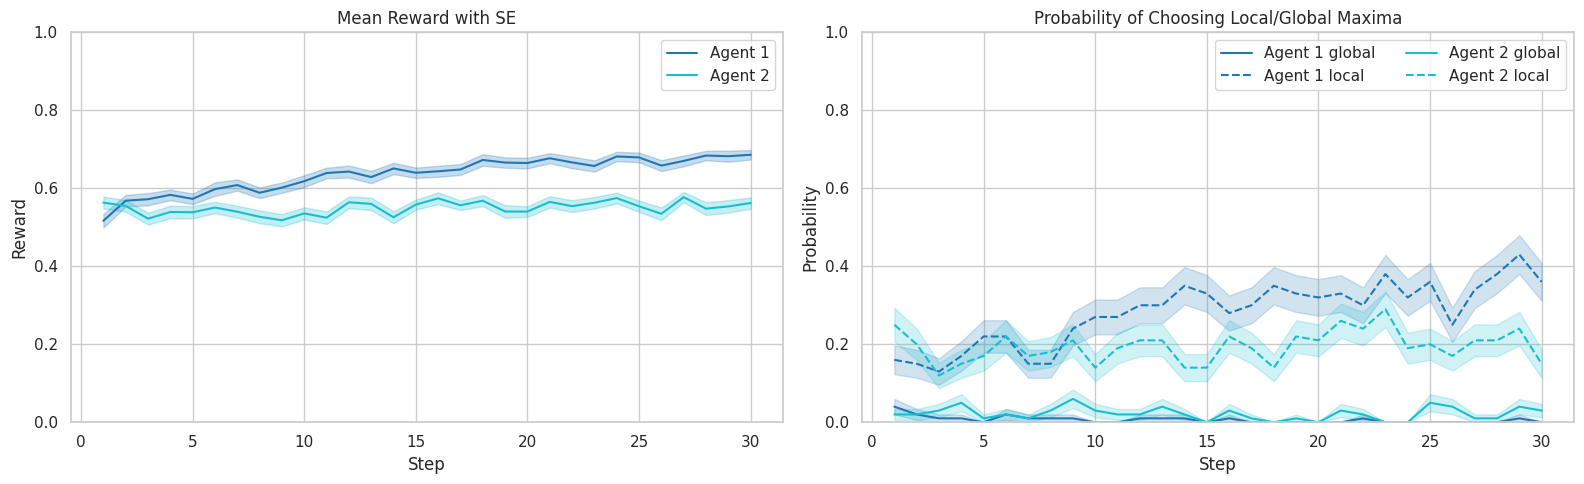

In [58]:
# Aggregate combined sweep output by step and agent
required_cols = ['Step', 'AgentID', 'reward', 'global_max', 'local_max']
missing_cols = [col for col in required_cols if col not in df_batch.columns]
if missing_cols:
    raise KeyError(f"df_batch is missing required columns: {missing_cols}")

df_plot = df_batch[required_cols].copy()

# Ensure numeric columns are numeric
for col in ['reward', 'global_max', 'local_max']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

df_grouped = (
    df_plot.groupby(['Step', 'AgentID'], as_index=False)
    .agg(
        reward_mean=('reward', 'mean'),
        reward_std=('reward', 'std'),
        reward_n=('reward', 'count'),
        global_max_mean=('global_max', 'mean'),
        global_max_std=('global_max', 'std'),
        global_max_n=('global_max', 'count'),
        local_max_mean=('local_max', 'mean'),
        local_max_std=('local_max', 'std'),
        local_max_n=('local_max', 'count'),
    )
)

# Plot mean reward and probabilities in adjacent subplots, one line per agent
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

agent_ids = sorted(df_grouped['AgentID'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(agent_ids)))

for color, agent_id in zip(colors, agent_ids):
    agent_df = df_grouped[df_grouped['AgentID'] == agent_id].sort_values('Step')

    reward_se = (agent_df['reward_std'] / np.sqrt(agent_df['reward_n'].clip(lower=1))).fillna(0.0)
    global_max_se = (agent_df['global_max_std'] / np.sqrt(agent_df['global_max_n'].clip(lower=1))).fillna(0.0)
    local_max_se = (agent_df['local_max_std'] / np.sqrt(agent_df['local_max_n'].clip(lower=1))).fillna(0.0)

    # Left: mean reward
    axes[0].plot(agent_df['Step'], agent_df['reward_mean'], label=f'Agent {int(agent_id)}', color=color)
    axes[0].fill_between(
        agent_df['Step'],
        agent_df['reward_mean'] - reward_se,
        agent_df['reward_mean'] + reward_se,
        alpha=0.25,
        color=color,
    )

    # Right: probabilities (solid=global, dashed=local)
    axes[1].plot(
        agent_df['Step'],
        agent_df['global_max_mean'],
        label=f'Agent {int(agent_id)} global',
        color=color,
        linestyle='-',
    )
    axes[1].fill_between(
        agent_df['Step'],
        agent_df['global_max_mean'] - global_max_se,
        agent_df['global_max_mean'] + global_max_se,
        alpha=0.20,
        color=color,
    )

    axes[1].plot(
        agent_df['Step'],
        agent_df['local_max_mean'],
        label=f'Agent {int(agent_id)} local',
        color=color,
        linestyle='--',
    )
    axes[1].fill_between(
        agent_df['Step'],
        agent_df['local_max_mean'] - local_max_se,
        agent_df['local_max_mean'] + local_max_se,
        alpha=0.20,
        color=color,
    )

axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].set_title('Probability of Choosing Local/Global Maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()